Homework 2\
DSCI 552\
Xander Lee

In [5]:
import os
import openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

***Combined Cycle Power Plant Data Set***

In [6]:
df = pd.read_excel("../data/CCPP/Folds5x2_pp.xlsx")

# Column names (without EP)
cols = list(df.columns[:-1])

a) From the text file, there are 9568 rows in this dataset and 5 columns. Features consist of hourly average ambient variables Temperature (AT), Exhaust Vacuum (V), Ambient Pressure (AP), and Relative Humidity (RH) to predict the net hourly electrical energy output (EP) of the plant. Rows consist of average hourly measurements of the Combined Cycle Power Plant over 6 years (2006-2011), when the power plant was set to work with a full load.

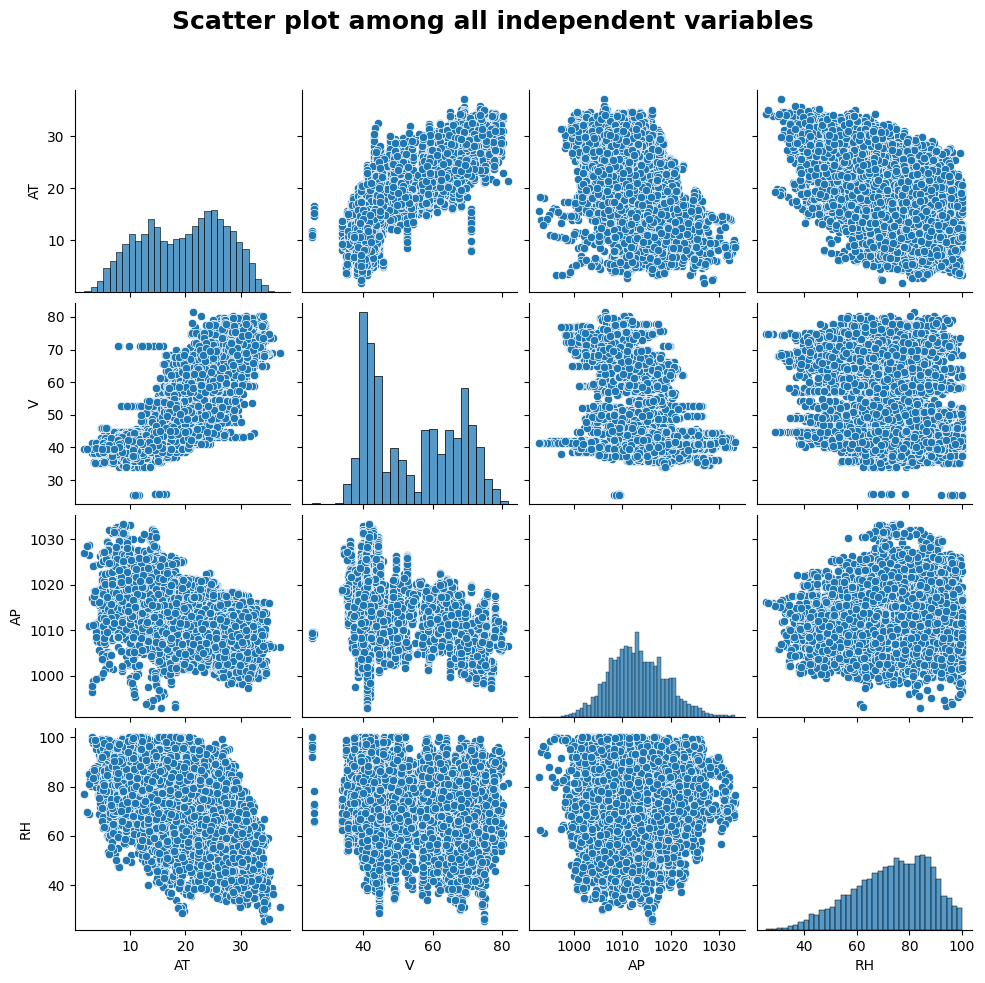

In [7]:
pairplot_fig = sns.pairplot(df, vars=cols)
plt.subplots_adjust(top=0.9)
pairplot_fig.figure.suptitle("Scatter plot among all independent variables", fontsize=18, weight='bold')
plt.show()

Temperature (AT) and Ambient Pressure (AP) seems to follow a relatively normal distribution, while Relative Humidity (RH) seems to be skewed left and Exhaust Vacuum (V) seems to follow a bi-peak distribution. The most obvious correlations are between AT and P (positive) and between AT and RH (negative). 

In [8]:
# Describe dataframe
desc = df.describe().round(2).drop(index=["min","max","count","std"])

# Calclulate full range and IQR for numeric columns
full_range = df.max() - df.min()
iqr = df.quantile(0.75) - df.quantile(0.25)

# Append to dataframe
desc.loc["range"] = full_range
desc.loc["IQR"] = iqr
desc.rename(index={"50%":"median"}, inplace=True)

# Reorder rows
desc_reordered = desc.reindex(["mean", "median", "range", "25%", "75%", "IQR"])

print(desc_reordered)

           AT      V       AP       RH      PE
mean    19.65  54.31  1013.26  73.3100  454.37
median  20.34  52.08  1012.94  74.9700  451.55
range   35.30  56.20    40.41  74.6000   75.50
25%     13.51  41.74  1009.10  63.3300  439.75
75%     25.72  66.54  1017.26  84.8300  468.43
IQR     12.21  24.80     8.16  21.5025   28.68


***Fitting a linear regression model***

Feature    Intercept  Intercept p-value     Slope  Slope p-value       R2  Outliers
     AT   497.034120                0.0 -2.171320            0.0 0.898948        70
      V   517.801526                0.0 -1.168135            0.0 0.756518       140
     AP -1055.260989                0.0  1.489872            0.0 0.268769        63
     RH   420.961766                0.0  0.455650            0.0 0.151939         0
____________________________________________________________________________________________________


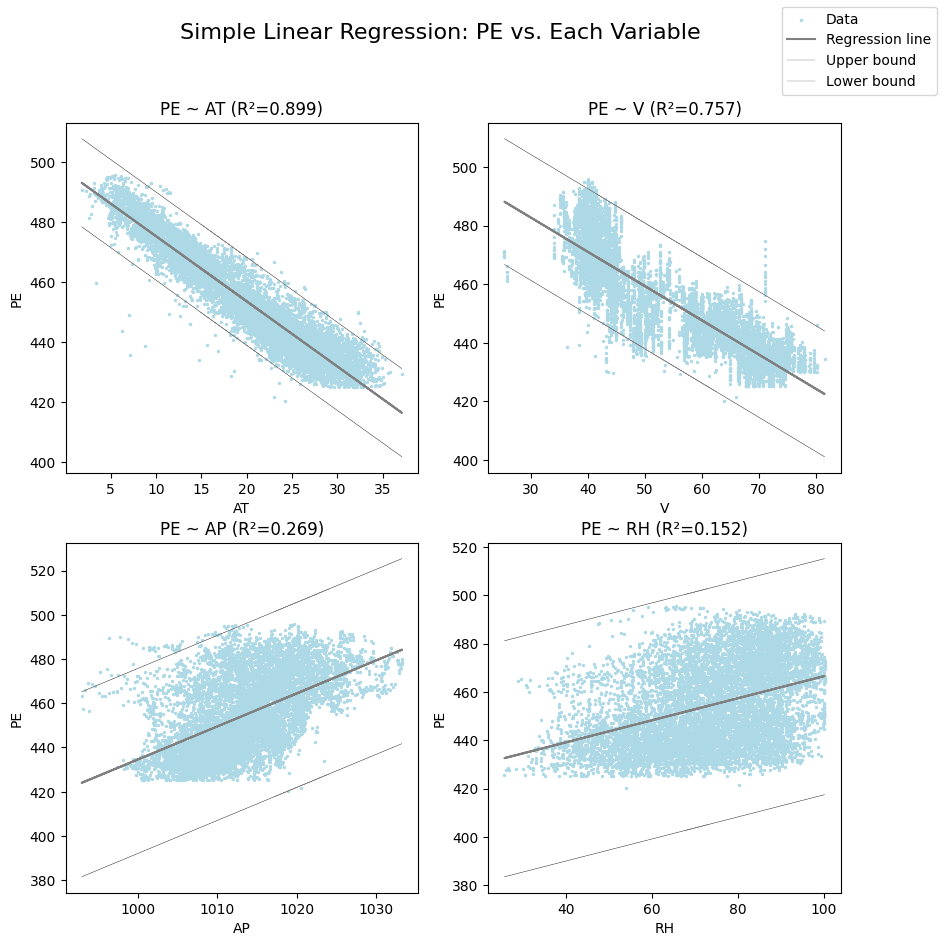

In [9]:
results = []
models = {}
bounds = {}

for col in cols:
    # Linear regression
    y = df["PE"]
    statmodel = smf.ols(formula=f"PE ~ {col}", data=df).fit()
    models[col] = statmodel

    # Outliers via IQR on residuals
    residuals = statmodel.resid
    q1, q3 = np.percentile(residuals, [25, 75])
    iqr = q3 - q1
    outliers = residuals[(residuals < q1-1.5*iqr) | (residuals > q3 + 1.5*iqr)]
    bounds[col] = (q1-1.5*iqr, q3 + 1.5*iqr)
    
    results.append({
        "Feature": col,
        "Intercept": statmodel.params["Intercept"],
        "Intercept p-value": statmodel.pvalues["Intercept"],
        "Slope": statmodel.params[col],
        "Slope p-value": statmodel.pvalues[col],
        "R2": statmodel.rsquared,
        "Outliers": outliers.size
    })
    
summary_uni = pd.DataFrame(results)
print(summary_uni.to_string(index=False))
print("_"*100)

# Visual
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    statmodel = models[col]
    fitted = statmodel.params["Intercept"] + statmodel.params[col] * df[col]
    lower_bound, upper_bound = bounds[col]
    
    ax.scatter(df[col], df["PE"], s=2, color="lightblue", label="Data")
    ax.plot(df[col], fitted, color="gray", label="Regression line")
    ax.plot(df[col], fitted + upper_bound, linewidth=0.3, 
         color="gray", label="Upper bound")
    ax.plot(df[col], fitted + lower_bound, linewidth=0.3, 
         color="gray", label="Lower bound")
    ax.set_title(f"PE ~ {col} (R²={statmodel.rsquared:.3f})")
    ax.set_xlabel(col)
    ax.set_ylabel("PE")

fig.suptitle("Simple Linear Regression: PE vs. Each Variable", fontsize=16)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.show()

There is a statistically significant association between all the predictors and the response. In other words, all the slope p-values are less than the significance level $\alpha = 0.05$. In fact, all the slope p-values are equal to 0. There are outliers in all the simple linear regression models, with the exception of PE ~ RH, since the IQR values in this case are quite large. However, because the sample sizes are quite large, there are no outliers that drastically change the linear regression for any of the models. No outliers need to be removed for these regression tasks.

***Fitting a multiple regression model***

In [10]:
statmodel_multi = smf.ols('PE ~ AT + V + AP + RH', data=df).fit()
print(statmodel_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        01:59:55   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

It seems that the regression coefficient for AP is positive while it is negative for every other independent variable. This is different than the results we would expect from the previous simple regression plot, and hints at correlation between variables (multicollinearity). Because the p-values of every predictor is less than the significance level $\alpha = 0.05$, we can reject the null hypothesis that the coefficient $\beta_j=0$ for every predictor.

***Comparing the univariate and multiple regression coefficients***

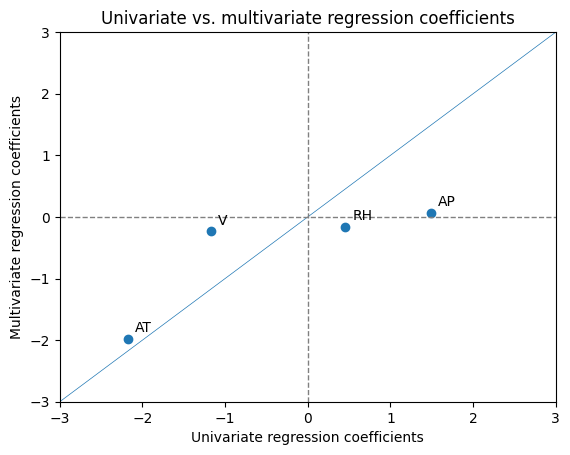

In [11]:
# Displaying the univariate regression coefficients on the x-axis
# Displaying the multivariate regression coeffiicents on the y-axis
uni_coef = summary_uni["Slope"]
multi_coef = statmodel_multi.params[1:]

labels = ["AT", "V", "AP", "RH"]
for i, label in enumerate(labels):
    plt.annotate(label, (uni_coef.iloc[i], multi_coef.iloc[i]), xytext=(5,5), textcoords="offset points")

plt.scatter(uni_coef, multi_coef)
plt.axline((0,0), slope=1, linewidth=0.5)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.xlabel("Univariate regression coefficients")
plt.ylabel("Multivariate regression coefficients")
plt.title("Univariate vs. multivariate regression coefficients")
plt.show()

The univariate regression coefficients and the multivariate regression coefficients are generally similar. The only regression coefficient that is not in quadrant 1 or 3, meaning the direction of the slope changed, is RH, which switched from positive to negative.

***Nonlinear associations***

In [12]:
# Centering the data to prevent collinearity 
# Collinearity = correlation between a multiplicative term and its component variable
dfc = pd.DataFrame()
for col in cols:
    dfc[col] = df[col] - df[col].mean()
dfc["PE"] = df["PE"]

In [13]:
results = []

for col in cols:
    # Polynomial regression
    model = smf.ols(formula=f"PE ~ {col} + I({col}**2) + I({col}**3)", data=dfc).fit()
    
    results.append({
        "Feature": col,
        "β0 (Intercept)": f"{model.params['Intercept']:.4f}",
        "p0": f"{model.pvalues['Intercept']:.4f}",
        "β1 (X)": f"{model.params[col]:.4f}",
        "p1": f"{model.pvalues[col]:.4f}",
        "β2 (X²)": f"{model.params[f'I({col} ** 2)']:.4f}",
        "p2": f"{model.pvalues[f'I({col} ** 2)']:.4f}",
        "β3 (X³)": f"{model.params[f'I({col} ** 3)']:.6f}",
        "p3": f"{model.pvalues[f'I({col} ** 3)']:.4f}",
        "R²": f"{model.rsquared:.3f}",
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Feature β0 (Intercept)     p0  β1 (X)     p1 β2 (X²)     p2   β3 (X³)     p3    R²
     AT       452.7081 0.0000 -2.4297 0.0000  0.0326 0.0000  0.002675 0.0000 0.912
      V       451.2137 0.0000 -1.2503 0.0000  0.0192 0.0000  0.000134 0.0137 0.775
     AP       453.0823 0.0000  1.9647 0.0000  0.0442 0.0000 -0.004991 0.0000 0.298
     RH       454.4430 0.0000  0.5302 0.0000 -0.0013 0.1014 -0.000152 0.0000 0.154


There is evidence of nonlinear association (significant polynomial coefficient terms) between all the predictors and the response under the significance level $\alpha = 0.05$. Relative Humidity (RH) does not have significant quadratic association. As the degree of polynomial increases, the coefficient of each feature tends to decrease in magnitude, but because third-degree polynomials are on a much larger numeric scale than first-degree polynomials, the effect on the final energy output (PE) is still uncertain, but significant.

***Interactions***

In [14]:
statmodel_interact = smf.ols('PE ~ AT * V * AP * RH', data=dfc).fit()
print(statmodel_interact.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     9568.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        01:59:56   Log-Likelihood:                -27450.
No. Observations:                9568   AIC:                         5.493e+04
Df Residuals:                    9552   BIC:                         5.505e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    452.6787      0.074   6122.653      0.0

Yes, there is evidence of association of interactions between almost all the predictors with the response, most notably between AT:V, AT:AP, V:AP, AT:V:AP, AT:RH, V:RH, AT:V:RH, AP:RH, and AT:V:AP:RH.

***Testing the regression model***

In [15]:
def fitevaluate(formula, df, cols=cols, train_size=0.7, random_state=99, figsize=(10,10), visualize=True):
    # X/Y split
    x = df[cols]
    y = df['PE']

    # Train test split
    x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=train_size, random_state=random_state)

    # Center according to training data
    for col in cols:
        mean = x_train[col].mean()
        x_train[col] = x_train[col] - mean
        x_test[col] = x_test[col] - mean

    # Rebuilding the training dataframe
    train_df = x_train.copy()
    train_df[y.name] = y_train

    # Model training
    results = smf.ols(formula, data=train_df).fit()

    # Get predictions on both sets
    train_preds = results.predict(x_train)
    test_preds = results.predict(x_test)

    # Calculate MSE
    mse_train = mean_squared_error(y_train, train_preds)
    mse_test = mean_squared_error(y_test, test_preds)

    # print("Training MSE:", round(mse_train, 3))
    # print("Test MSE:", round(mse_test, 3))

    # Plotting the fit and residuals (turned OFF to reduce clutter)
    if visualize:
        # Visualize
        fig, axes = plt.subplots(2,2,figsize=figsize)
        axes = axes.flatten()
    
        # Plotting training set
        sns.scatterplot(x=y_train,y=train_preds,alpha=0.4,ax=axes[0])
        axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
                     color='red', linestyle='--', label='Perfect prediction')
        axes[0].set_xlabel("Actual PE")
        axes[0].set_ylabel("Predicted PE")
        axes[0].set_title(f"Training Set (MSE={mse_train:.2f})")
        axes[0].legend()
    
        # Plotting test set
        sns.scatterplot(x=y_test, y=test_preds, alpha=0.4, ax=axes[1])
        axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                     color='red', linestyle='--', label='Perfect prediction')
        axes[1].set_xlabel("Actual PE")
        axes[1].set_ylabel("Predicted PE")
        axes[1].set_title(f"Test Set (MSE={mse_test:.2f})")
        axes[1].legend()
    
        # Plotting residuals
        train_resid = y_train - train_preds
        test_resid = y_test - test_preds
    
        # Plotting training residuals
        sns.scatterplot(x=train_preds, y=train_resid, alpha=0.4, ax=axes[2])
        axes[2].axhline(0, color='red', linestyle='--')
        axes[2].set_xlabel("Predicted PE")
        axes[2].set_ylabel("Residual (Actual - Predicted)")
        axes[2].set_title("Training Residuals")
    
        # Plotting test residuals
        sns.scatterplot(x=test_preds, y=test_resid, alpha=0.4, ax=axes[3])
        axes[3].axhline(0, color='red', linestyle='--')
        axes[3].set_xlabel("Predicted PE")
        axes[3].set_ylabel("Residual (Actual - Predicted)")
        axes[3].set_title("Test Residuals")
    
        plt.tight_layout()
        plt.show()

    return mse_train, mse_test

In [16]:
# Over 100 trials, comparing the MSE on the training and test sets
fit_results = pd.DataFrame(columns=["Model", "Avg Train MSE", "Avg Test MSE", "Std Test MSE"])

formulas = {
    "Multiple regression": 'PE ~ AT + V + AP + RH',
    "Interaction model": 'PE ~ AT * V * AP * RH',
    "Interaction/quadratic model": 'PE ~ AT * V * AP * RH + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)',
}

for name, formula in formulas.items():
    train_mses, test_mses = [], []
    for i in range(10):
        mse_train, mse_test = fitevaluate(formula, df, random_state=i, visualize=False)
        train_mses.append(mse_train)
        test_mses.append(mse_test)

    fit_results.loc[len(fit_results)] = [
        name,
        np.mean(train_mses),
        np.mean(test_mses),
        np.std(test_mses),
    ]

print(fit_results)    

                         Model  Avg Train MSE  Avg Test MSE  Std Test MSE
0          Multiple regression      20.912788     20.440752      0.419362
1            Interaction model      18.335541     17.837012      0.442985
2  Interaction/quadratic model      17.871147     17.405396      0.481199


The interaction model is better than the plain multiple regression model, but the interaction/quadratic model is only marginally better than the interaction model.

***KNN Regression***

[Raw] Smallest test MSE is 15.651 at k = 5
[Scaled] Smallest test MSE is 14.534 at k = 4


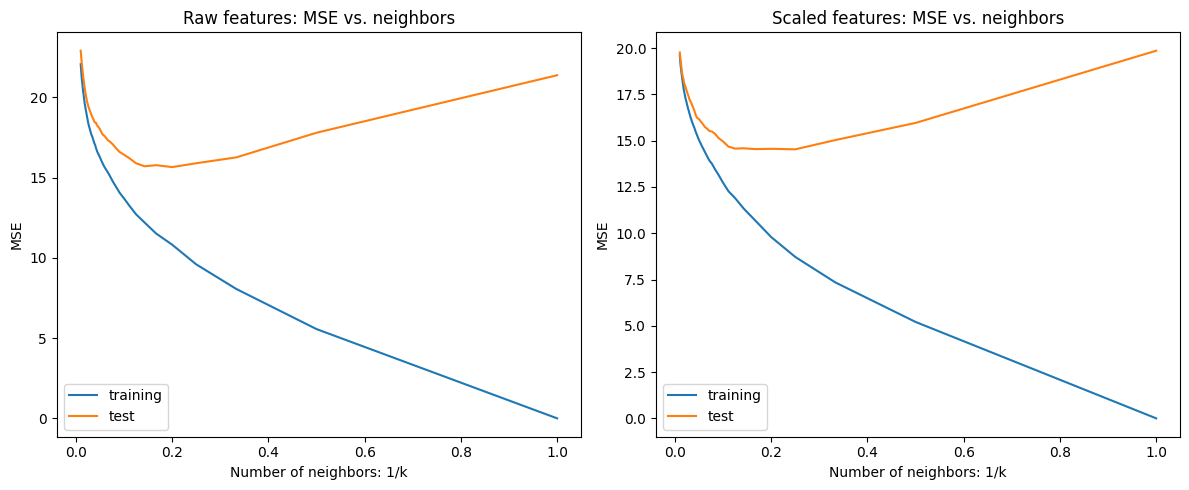

In [17]:
# RAW/NORMALIZED FEATURE ANALYSIS

# Train test split 70/30
x = df[cols]
y = df['PE']
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, random_state=99)

# Standardization
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

k_range = list(range(1, 101))
mse_train_raw = []
mse_test_raw = []
mse_train_scaled = []
mse_test_scaled = []

for k in k_range:
    knn_raw = KNeighborsRegressor(n_neighbors=k)
    knn_raw.fit(x_train, y_train)
    y_pred_train_raw = knn_raw.predict(x_train)
    y_pred_test_raw = knn_raw.predict(x_test)
    mse_train_raw.append(mean_squared_error(y_train, y_pred_train_raw))
    mse_test_raw.append(mean_squared_error(y_test, y_pred_test_raw))

    knn_scaled = KNeighborsRegressor(n_neighbors=k)
    knn_scaled.fit(x_train_scaled, y_train)
    y_pred_train_scaled = knn_scaled.predict(x_train_scaled)
    y_pred_test_scaled = knn_scaled.predict(x_test_scaled)
    mse_train_scaled.append(mean_squared_error(y_train, y_pred_train_scaled))
    mse_test_scaled.append(mean_squared_error(y_test, y_pred_test_scaled))

best_k_raw = k_range[np.argmin(mse_test_raw)]
best_mse_raw = min(mse_test_raw)
print(f"[Raw] Smallest test MSE is {best_mse_raw:.3f} at k = {best_k_raw}")

best_k_scaled = k_range[np.argmin(mse_test_scaled)]
best_mse_scaled = min(mse_test_scaled)
print(f"[Scaled] Smallest test MSE is {best_mse_scaled:.3f} at k = {best_k_scaled}")

table = pd.DataFrame({
    "k": k_range,
    "Training error (raw)": mse_train_raw,
    "Test error (raw)": mse_test_raw,
    "Training error (scaled)": mse_train_scaled,
    "Test error (scaled)": mse_test_scaled})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(1/np.array(k_range), mse_train_raw, label="training")
axes[0].plot(1/np.array(k_range), mse_test_raw, label="test")
axes[0].set_title("Raw features: MSE vs. neighbors")
axes[0].set_xlabel("Number of neighbors: 1/k")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(1/np.array(k_range), mse_train_scaled, label="training")
axes[1].plot(1/np.array(k_range), mse_test_scaled, label="test")
axes[1].set_title("Scaled features: MSE vs. neighbors")
axes[1].set_xlabel("Number of neighbors: 1/k")
axes[1].set_ylabel("MSE")
axes[1].legend()

plt.tight_layout()
plt.show()

KNN regression gives a best test error of 14.534 at k = 4 for scaled/normalized features. The interaction quadratic model gave a best test error of 17.405. This may because KNN, being nonparametric, can trace a smooth curvature more flexibly than a fixed-degree polynomial can. 

***ISLR: 2.4.1***

For each of the following parts, indicate whether we would generally expect the performance of a flexible statistical learning method to be better or worse than an inflexible method:

a) The sample size n is extremely large, and the number of predictors p is small: **Flexible**

Given many observations and a small number of predictors, flexible methods can capture complex patterns without overfitting. In other words, there is enough data to keep variance in check that the bias-reduction benefit of flexibility comes essentially for free. 

b) The number of predictors p is extremely large, and the number of observations n is small: **Inflexible**

Flexible models are prone to overfitting when there is noise due to many predictors relative to the number of observations (high variance). Inflexible models allow for generalization.

c) The relationship between the predictors and the response is highly non-linear: **Flexible**

Inflexible methods will impose a specific functional form, and the model will suffer from high bias.

d) The varaince of the error terms is extremeley high: **Inflexible**

Lots of noise can result in overfitting for a model with high variance. An inflexible method can generalize more reliably when the signal-to-noise ratio is poor.

***ISLR: 2.4.7***

Given the following table (six observations, three predictors, one qualitative response variable), we wish to make a prediction for Y when X1 = X2 = X3 = 0 using K-nearest neighbors.

In [18]:
data = [[0,3,0,"Red"],[2,0,0,"Red"],[0,1,3,"Red"],[0,1,2,"Green"],[-1,0,1,"Green"],[1,1,1,"Red"]]
df = pd.DataFrame(data, columns=["X1","X2","X3","Y"])
df.index += 1
print(df)

   X1  X2  X3      Y
1   0   3   0    Red
2   2   0   0    Red
3   0   1   3    Red
4   0   1   2  Green
5  -1   0   1  Green
6   1   1   1    Red


a) The Euclidean distance between each observation and the test point X1=X2=X3=0:

1: 3

2: 2

3: $\sqrt{1^2+3^2}=\sqrt{10}$

4: $\sqrt{1^2+2^2}=\sqrt{5}$

5: $\sqrt{-1^2+1^2}=\sqrt{2}$

6: $\sqrt{1^2+1^2+1^2}=\sqrt{3}$

b) The prediction with K = 1 is **green**. The nearest neighbor to the test point is point 5, which is green.

c) The prediction with K = 3 is **red**. The 3 nearest neighbors to the test point are points 2, 5, and 6. Two are red, and one is green, so the final prediction is red.

d) If the Bayes decision boundary is highly non-linear, then we would expect the best value for K would be **small**. A small K means each prediction is based on few neighbors, so the decision boundary can follow tight, local curves in the path. It has low-bias, whereas a large K would smooth the boundary too much.

***References and Citations***

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html

https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbors-knn-regression-with-scikit-learn/